<a id="parameter-transformations"></a>

# Sample your first posterior

Fit a Gaussian regression with NUTS, inspect the chains, and use the draws to
estimate the regression mean. You should already know how to
{doc}`build a Liesel model <../../model-building>`. This page includes the complete setup
and samples both the coefficients and the noise variance.

For transformation semantics and short recipes, see
{doc}`../../model-transformations`.

## Build the model

We simulate 500 observations with intercept 1, slope 2, and noise standard
deviation 1. Independent normal priors describe the two coefficients, and an
inverse-gamma prior keeps the variance positive.

In [1]:
import jax.numpy as jnp
import numpy as np
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.bijectors as tfb
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl

# Simulate regression observations.
rng = np.random.default_rng(42)
n = 500
true_beta = np.array([1.0, 2.0])
true_sigma = 1.0
x = rng.uniform(size=n)
X_mat = np.column_stack([np.ones(n), x])
y_vec = X_mat @ true_beta + rng.normal(scale=true_sigma, size=n)

# Define the priors.
beta = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, 0.0, 5.0),
    name="beta",
)
sigma_sq = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.InverseGamma, concentration=3.0, scale=2.0),
    name="sigma_sq",
)

# Connect the parameters to the observations.
sigma = lsl.Var.new_calc(jnp.sqrt, sigma_sq, name="sigma")
X = lsl.Var.new_obs(X_mat, name="X")
mu = lsl.Var.new_calc(jnp.dot, X, beta, name="mu")
y = lsl.Var.new_obs(
    y_vec,
    dist=lsl.Dist(tfd.Normal, mu, sigma),
    name="y",
)

## Transform the variance

NUTS uses gradients with respect to unconstrained parameters. Transform the positive
variance with an exponential bijector and name its unconstrained counterpart
`log_sigma_sq`:

In [2]:
sigma_sq.biject(tfb.Exp(), name="log_sigma_sq")
log_sigma_sq = sigma_sq.bijected_var

The model still describes the same prior on the variance. If
$\eta=\log(\sigma^2)$, the transformed density is
$p_\eta(\eta)=p_{\sigma^2}(e^\eta)e^\eta$.
{meth}`~liesel.model.Var.biject` includes this change-of-variables factor.
Choosing a new normal prior on $\eta$ and exponentiating it would instead
define a different prior on $\sigma^2$.

## Choose a joint update

Give the coefficients and log variance the same explicit `kernel_group`:

In [3]:
joint = gs.MCMCSpec(
    gs.NUTSKernel,
    kernel_group="regression",
    jitter_dist=tfd.Normal(0.0, 0.2),
)
beta.inference = joint
log_sigma_sq.inference = joint
model = lsl.Model(y)

One NUTS kernel now updates both coefficients and the log variance together.
The jitter distribution perturbs each chain's initial values on these
unconstrained scales. Without a configured jitter distribution, Goose uses the
model's starting values for every chain.

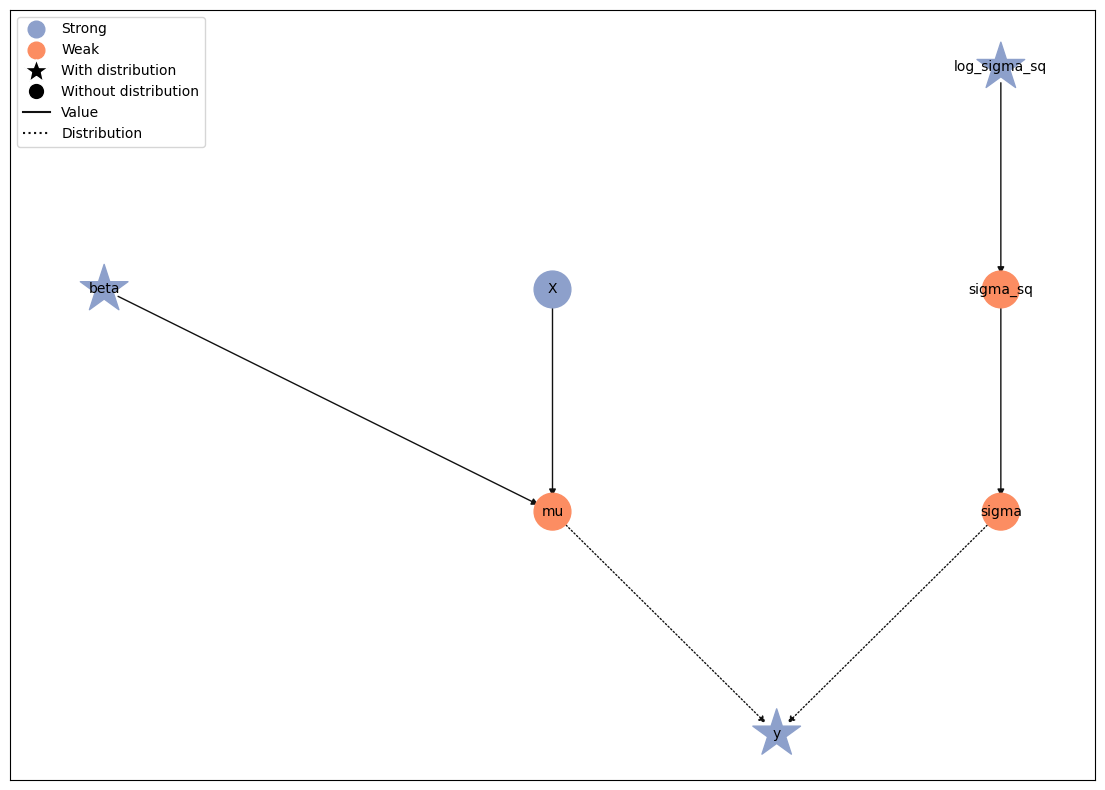

In [4]:
model.plot()

The graph separates the sampled `log_sigma_sq` from its deterministic
transformation `sigma_sq`. The likelihood receives the standard deviation
`sigma`, computed as the square root of the variance.

## Run several chains

In [5]:
results = gs.LieselMCMC(model).run_for_epochs(
    seed=1,
    num_chains=4,
    adaptation=1000,
    posterior=1000,
    positions_included=["sigma_sq"],
    show_progress=False,
)

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


Each chain runs 1,000 adaptation iterations followed by 1,000 posterior
iterations. Adaptation tunes the kernel; only the posterior phase supplies
draws for inference. These are example settings, not a guarantee of adequate
sampling. `positions_included` records the variance on its original scale
as well as the parameters updated by NUTS.

## Inspect the chains

In [6]:
summary = gs.Summary(results, selected=["beta", "sigma_sq"])

In [7]:
summary.to_dataframe().set_index("var_fqn")[
    ["mean", "sd", "q_0.05", "q_0.95", "mcse_mean"]
].round(3)

,mean,sd,q_0.05,q_0.95,mcse_mean
var_fqn,,,,,
beta[0],0.990,0.091,0.839,1.140,0.002
beta[1],1.899,0.158,1.642,2.164,0.004
sigma_sq,1.039,0.065,0.937,1.151,0.001


The posterior means are about 0.99 for the intercept, 1.90 for the slope,
and 1.04 for the variance, compared with generating values of 1, 2, and 1.
Finite data and
the priors mean the estimates need not equal the generating values.
Posterior standard deviations describe uncertainty in the parameters;
Monte Carlo standard errors describe the numerical precision of the estimates.

In [8]:
summary.aggregate_diagnostics().round(3)

,ess_bulk,ess_tail,rhat,aggregated_by
parameter,,,,
beta,1432.583,1540.084,1.005,min (ess); max (rhat)
sigma_sq,2172.744,1970.398,1.003,min (ess); max (rhat)


In this run, the largest R-hat is about 1.004 and the smallest bulk ESS is
about 1,680 across the displayed parameters. For a vector such as `beta`, this table reports its lowest bulk/tail ESS and
largest R-hat. Check all the parameters, not only one well-behaved coefficient.

In [9]:
summary.error_df().reset_index().filter(["error_msg", "phase", "count"])

,error_msg,phase,count
0,divergent transition,warmup,50
1,divergent transition,posterior,0


This run records divergences during warmup and none in the posterior phase.
The error table separates warmup from posterior sampling. An error while the
sampler is adapting has a different context from one persisting in the
posterior phase; inspect the message and phase before deciding what to change.

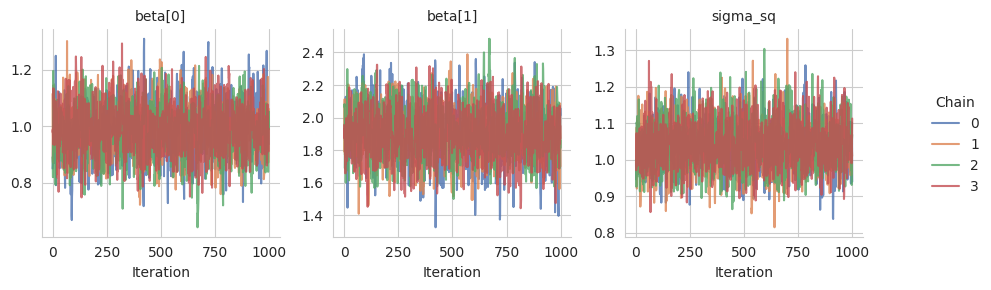

In [10]:
gs.plot_trace(results, params=["beta", "sigma_sq"])

Look for overlap, drift, and long periods without movement. The traces must
be read alongside the numerical diagnostics; appearance alone cannot establish
convergence. See {doc}`../../goose-diagnostics` for interpreting sampler errors,
ESS, R-hat, and MCSE.

## Use the draws

In [11]:
samples = results.get_posterior_samples()
sample_shapes = pd.DataFrame(
    {
        "Variable": ["beta", "sigma_sq"],
        "Shape": [samples["beta"].shape, samples["sigma_sq"].shape],
    },
)

In [12]:
sample_shapes

,Variable,Shape
0,beta,"(4, 1000, 2)"
1,sigma_sq,"(4, 1000)"


The first two axes are chains and posterior draws. The coefficient array's
last axis contains the intercept and slope. Warmup is excluded.

Predict the mean at new covariate values, retaining the design matrix's
intercept column:

In [13]:
x_grid = jnp.linspace(0.0, 1.0, 100)
X_grid = jnp.column_stack([jnp.ones_like(x_grid), x_grid])

pred = model.predict(
    samples,
    predict=["mu"],
    newdata={"X": X_grid},
)
prediction = gs.SamplesSummary(pred, which=["quantiles"]).to_dataframe()
prediction["x"] = np.asarray(x_grid)
prediction["true_mean"] = 1.0 + 2.0 * prediction["x"]

observations = pd.DataFrame({"x": x, "y": y_vec})

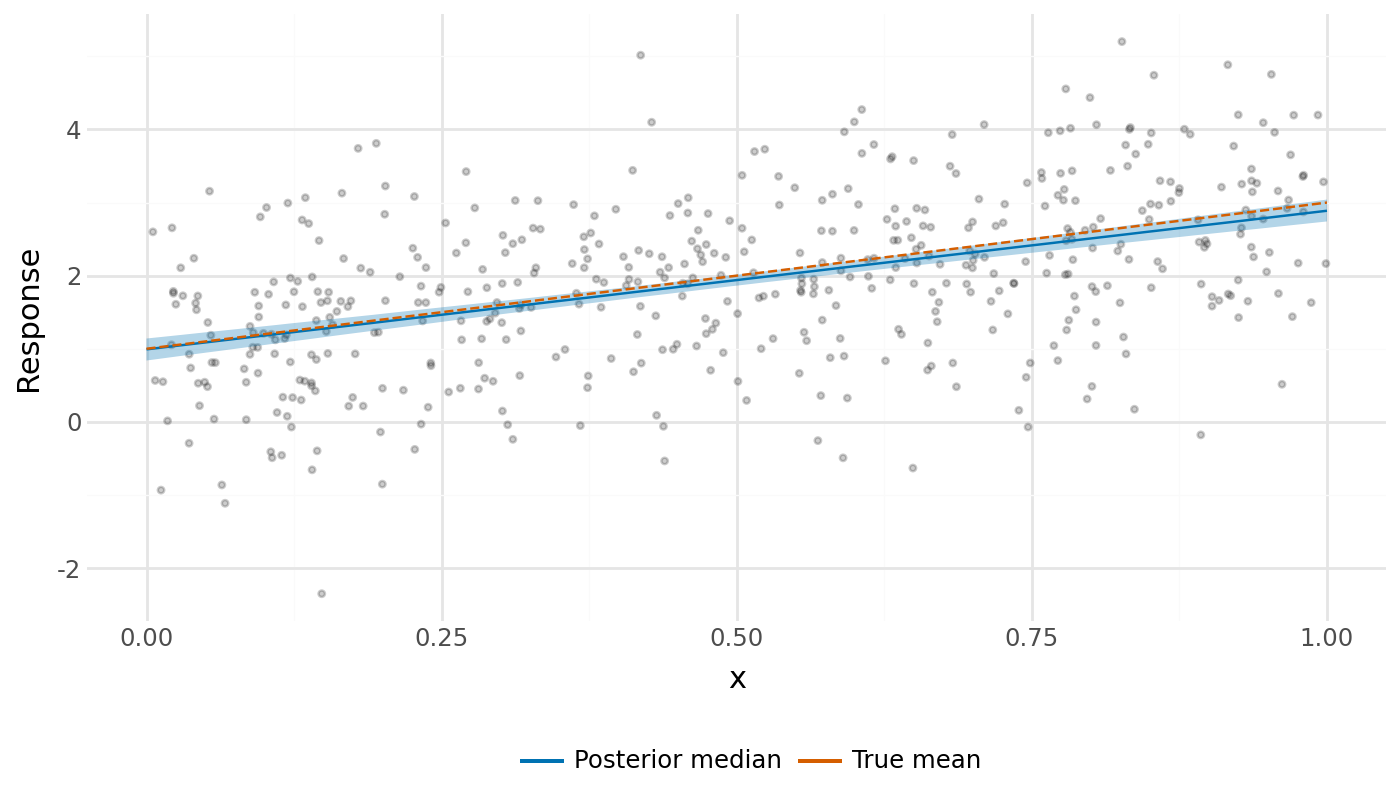

In [14]:
(
    p9.ggplot(prediction, p9.aes("x"))
    + p9.geom_point(
        p9.aes(y="y"),
        data=observations,
        alpha=0.2,
        size=0.8,
    )
    + p9.geom_ribbon(
        p9.aes(ymin="q_0.05", ymax="q_0.95"),
        fill="#0072B2",
        alpha=0.3,
    )
    + p9.geom_line(p9.aes(y="q_0.5", color='"Posterior median"'))
    + p9.geom_line(
        p9.aes(y="true_mean", color='"True mean"'),
        linetype="dashed",
    )
    + p9.scale_color_manual(
        values={"Posterior median": "#0072B2", "True mean": "#D55E00"},
    )
    + p9.labs(x="x", y="Response", color="")
    + p9.theme_minimal()
    + p9.theme(figure_size=(7, 4), legend_position="bottom")
)

The band describes pointwise uncertainty in the **mean**. It does not describe
the spread of individual observations. See {doc}`../../goose-results` to
simulate responses and obtain predictive intervals.

Next, {doc}`combine NUTS and Gibbs updates <01d-gibbs-sampling>` for the same
statistical model, or {doc}`choose different parameter blocks <../../goose-kernels>`.